# **Practice Assignment - Part 1: Analyzing wildfire activities in Australia** 

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [50]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Historical_Wildfires.csv"

df = pd.read_csv(URL)

In [51]:
df.head()

,Region,Date,Estimated_fire_area,Mean_estimated_fire_brightness,Mean_estimated_fire_radiative_power,Mean_confidence,Std_confidence,Var_confidence,Count,Replaced
0,NSW,1/4/2005,8.68000,312.266667,42.400000,78.666667,2.886751,8.333333,3,R
1,NSW,1/5/2005,16.61125,322.475000,62.362500,85.500000,8.088793,65.428571,8,R
2,NSW,1/6/2005,5.52000,325.266667,38.400000,78.333333,3.214550,10.333333,3,R
3,NSW,1/7/2005,6.26400,313.870000,33.800000,92.200000,7.529940,56.700000,5,R
4,NSW,1/8/2005,5.40000,337.383333,122.533333,91.000000,7.937254,63.000000,3,R


In [52]:
df.columns

Index(['Region', 'Date', 'Estimated_fire_area',
       'Mean_estimated_fire_brightness', 'Mean_estimated_fire_radiative_power',
       'Mean_confidence', 'Std_confidence', 'Var_confidence', 'Count',
       'Replaced'],
      dtype='object')

In [53]:
df.dtypes

Region                                  object
Date                                    object
Estimated_fire_area                    float64
Mean_estimated_fire_brightness         float64
Mean_estimated_fire_radiative_power    float64
Mean_confidence                        float64
Std_confidence                         float64
Var_confidence                         float64
Count                                    int64
Replaced                                object
dtype: object

In [54]:
df['Year'] = pd.to_datetime(df['Date']).dt.year
df['Month'] = pd.to_datetime(df['Date']).dt.month

In [55]:
df.columns

Index(['Region', 'Date', 'Estimated_fire_area',
       'Mean_estimated_fire_brightness', 'Mean_estimated_fire_radiative_power',
       'Mean_confidence', 'Std_confidence', 'Var_confidence', 'Count',
       'Replaced', 'Year', 'Month'],
      dtype='object')

In [56]:
df.dtypes

Region                                  object
Date                                    object
Estimated_fire_area                    float64
Mean_estimated_fire_brightness         float64
Mean_estimated_fire_radiative_power    float64
Mean_confidence                        float64
Std_confidence                         float64
Var_confidence                         float64
Count                                    int64
Replaced                                object
Year                                     int32
Month                                    int32
dtype: object

In [57]:
# ASK 1.1: Let's try to understand the change in average estimated fire area over time
# (use pandas to plot)

In [58]:
df['Estimated_fire_area'].head()

0     8.68000
1    16.61125
2     5.52000
3     6.26400
4     5.40000
Name: Estimated_fire_area, dtype: float64

In [59]:
df_group = df.groupby('Year')['Estimated_fire_area'].mean().reset_index()
df_group.head()

,Year,Estimated_fire_area
0,2005,92.770501
1,2006,176.289434
2,2007,153.112464
3,2008,99.758968
4,2009,141.624955


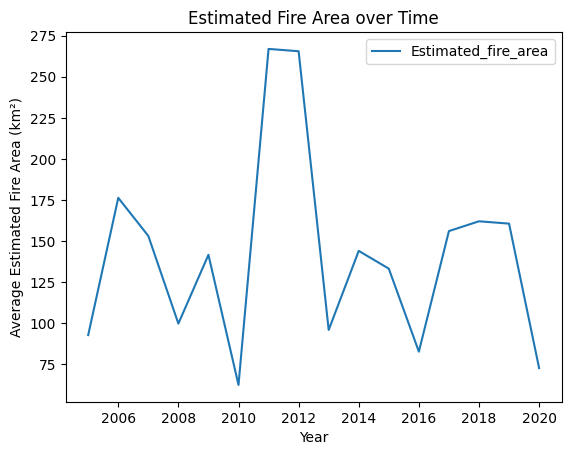

In [60]:
df_group.plot( x = 'Year', y = 'Estimated_fire_area')
plt.xlabel('Year')
plt.ylabel('Average Estimated Fire Area (km²)')
plt.title('Estimated Fire Area over Time')
plt.show()

In [61]:
# TASK 1.2: You can notice the peak in the plot between 2010 to 2013. 
# Let's narrow down our finding, by plotting the estimated fire area for year grouped together with month.

In [62]:
df_new =  df.groupby(['Month'])['Estimated_fire_area'].mean().reset_index()
df_new.head()

,Month,Estimated_fire_area
0,1,101.255540
1,2,58.493869
2,3,38.245106
3,4,77.498305
4,5,87.579229


<Axes: xlabel='Month'>

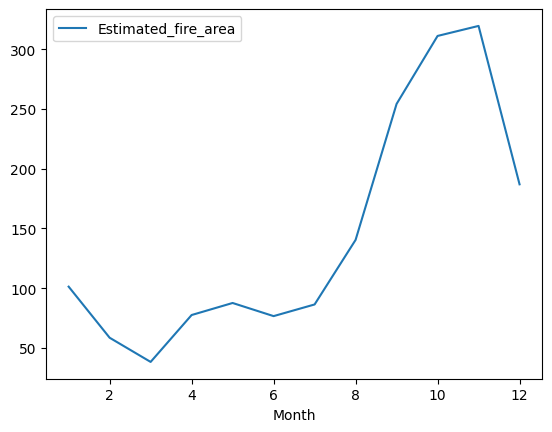

In [63]:
df_new.plot(x = 'Month',y = 'Estimated_fire_area')

In [64]:
# TASK 1.3: Let's have an insight on the distribution of mean estimated fire brightness across the regions
#  use the functionality of seaborn to develop a barplot


In [65]:
df['Region'].unique()

array(['NSW', 'NT', 'QL', 'SA', 'TA', 'VI', 'WA'], dtype=object)

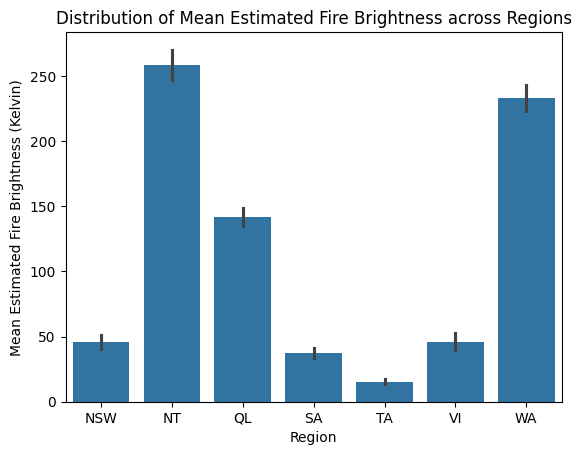

In [66]:
sns.barplot(data = df ,x = 'Region', y = 'Estimated_fire_area')
plt.xlabel('Region')
plt.ylabel('Mean Estimated Fire Brightness (Kelvin)')
plt.title('Distribution of Mean Estimated Fire Brightness across Regions')
plt.show()

In [67]:
# TASK 1.4: Let's find the portion of count of pixels for presumed vegetation fires vary across regions
# we will develop a pie chart for this

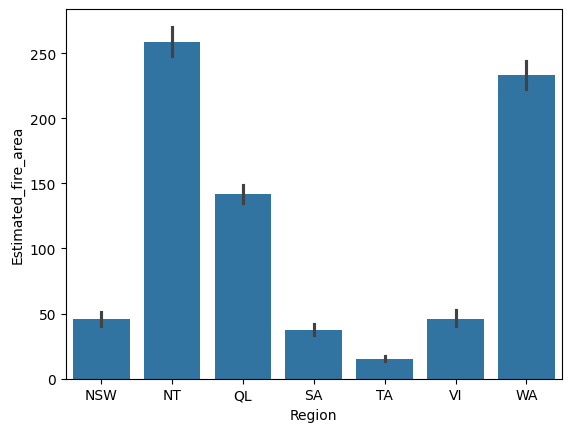

In [68]:
sns.barplot(data = df ,x = 'Region', y = 'Estimated_fire_area')
plt.show()

In [69]:
# TASK 1.4: Let's find the portion of count of pixels for presumed vegetation fires vary across regions
# we will develop a pie chart for this

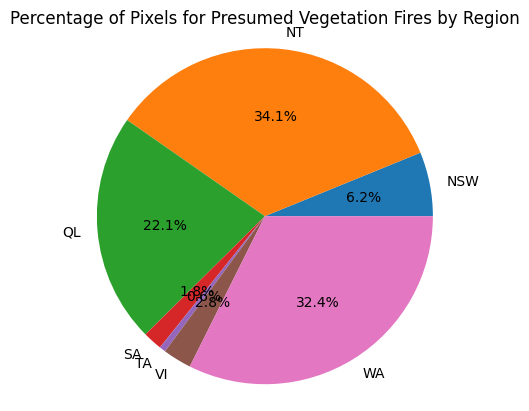

In [70]:
df_pie = df.groupby(['Region'])['Count'].sum().reset_index()

plt.pie(df_pie['Count'],labels = df_pie['Region'],autopct='%1.1f%%')
plt.title('Percentage of Pixels for Presumed Vegetation Fires by Region')
plt.axis('equal')
plt.show()

In [71]:
df_pie

,Region,Count
0,NSW,117412
1,NT,649430
2,QL,420882
3,SA,35160
4,TA,11473
5,VI,52473
6,WA,615968


In [72]:
# TASK 1.5: See the percentage on the pie is not looking so good as it is overlaped for Region SA, TA, VI

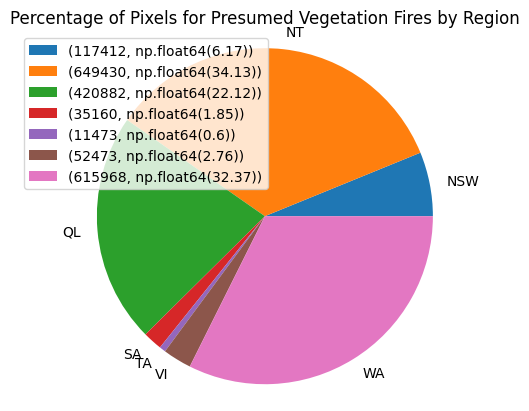

In [73]:
plt.pie(df_pie['Count'],labels = df_pie['Region'])
plt.title('Percentage of Pixels for Presumed Vegetation Fires by Region')
plt.legend([(i,round(k/df_pie['Count'].sum()*100,2)) for i,k in zip(df_pie['Count'], df_pie['Count'])])
plt.axis('equal')
plt.show()

In [74]:
# # ASK 1.6: Let's try to develop a histogram of the mean estimated fire brightness
# Using Matplotlib to create the histogram

In [75]:
df.columns

Index(['Region', 'Date', 'Estimated_fire_area',
       'Mean_estimated_fire_brightness', 'Mean_estimated_fire_radiative_power',
       'Mean_confidence', 'Std_confidence', 'Var_confidence', 'Count',
       'Replaced', 'Year', 'Month'],
      dtype='object')

(array([3.3200e+02, 2.6460e+03, 8.1420e+03, 1.0336e+04, 4.1960e+03,
        6.1500e+02, 1.1400e+02, 1.6000e+01, 6.0000e+00, 3.0000e+00]),
 array([290.7  , 299.825, 308.95 , 318.075, 327.2  , 336.325, 345.45 ,
        354.575, 363.7  , 372.825, 381.95 ]),
 <BarContainer object of 10 artists>)

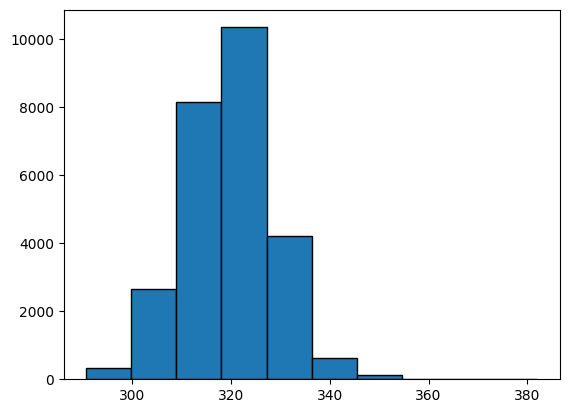

In [76]:
plt.hist(df['Mean_estimated_fire_brightness'],bins = 10,edgecolor = 'black')

In [77]:
# TASK 1.7: What if we need to understand the distribution of estimated fire brightness across regions? 
# Let's use the functionality of seaborn and pass region as hue

<Axes: xlabel='Mean_estimated_fire_brightness', ylabel='Count'>

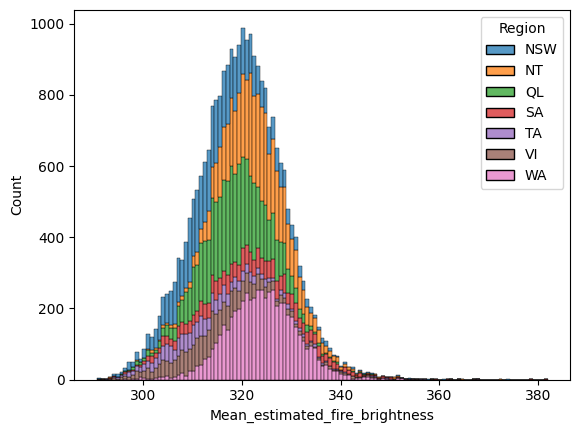

In [78]:
sns.histplot(data = df,x = 'Mean_estimated_fire_brightness',hue = 'Region',multiple='stack')

In [79]:
# TASK 1.8: Let's try to find if there is any correlation between mean estimated fire radiative power and mean confidence level?

In [80]:
df.columns

Index(['Region', 'Date', 'Estimated_fire_area',
       'Mean_estimated_fire_brightness', 'Mean_estimated_fire_radiative_power',
       'Mean_confidence', 'Std_confidence', 'Var_confidence', 'Count',
       'Replaced', 'Year', 'Month'],
      dtype='object')

<Axes: xlabel='Mean_confidence', ylabel='Mean_estimated_fire_radiative_power'>

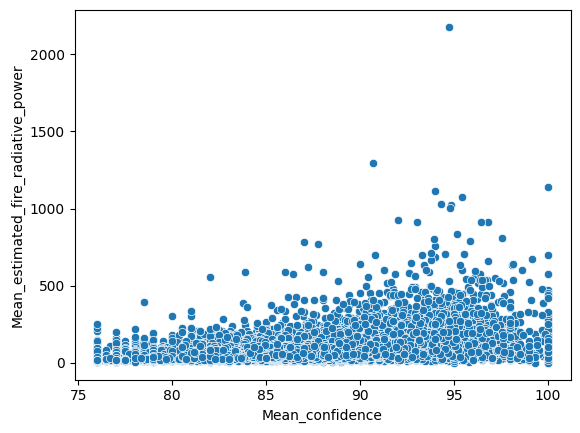

In [81]:
sns.scatterplot(y = df['Mean_estimated_fire_radiative_power'], x=  df['Mean_confidence'])

In [82]:
# TASK 1.9: Let's mark these seven regions on the Map of Australia using Folium

In [83]:
region_data = {'region':['NSW','QL','SA','TA','VI','WA','NT'], 'Lat':[-31.8759835,-22.1646782,-30.5343665,-42.035067,-36.5986096,-25.2303005,-19.491411], 
               'Lon':[147.2869493,144.5844903,135.6301212,146.6366887,144.6780052,121.0187246,132.550964]}
reg=pd.DataFrame(region_data)
reg

,region,Lat,Lon
0,NSW,-31.875984,147.286949
1,QL,-22.164678,144.584490
2,SA,-30.534367,135.630121
3,TA,-42.035067,146.636689
4,VI,-36.598610,144.678005
5,WA,-25.230300,121.018725
6,NT,-19.491411,132.550964


In [84]:
aus_reg = folium.map.FeatureGroup()

aus_map = folium.Map(location = [-25,135],zoom_start = 4)

for lat,lng,lab in zip(reg.Lat,reg.Lon,reg.region):
    aus_reg.add_child(folium.features.CircleMarker([lat,lng],popup = lab,radius = 5,
                                                   color = 'red',
                                                   fill = True,
                                                   fill_color = 'blue',
                                                   fill_opacity = 0.6))
    
aus_map.add_child(aus_reg)
aus_map